# Laboratorium 11: Transformata Hougha – Detektor prostych

**Cel laboratorium:** Zapoznanie się z transformatą Hougha jako metodą wykrywania prostych na obrazach oraz implementacja detektora linii.

---

## 1. Teoria

### 1.1. Wprowadzenie

**Transformata Hougha** to technika wykrywania kształtów geometrycznych na obrazach, szczególnie przydatna do detekcji linii prostych, okręgów i innych parametrycznych krzywych. Została wynaleziona przez Paula Hougha w 1962 roku i od tego czasu stała się jedną z podstawowych metod w dziedzinie przetwarzania obrazów i wizji komputerowej.

Główne zastosowania transformaty Hougha:
- Detekcja linii prostych (np. krawędzie dróg, budynków)
- Wykrywanie okręgów (np. źrenice oczu, monety)
- Analiza dokumentów (wykrywanie linii tekstu)
- Robotyka i nawigacja autonomiczna

### 1.2. Reprezentacja prostej

Klasyczna postać równania prostej $y = mx + b$ nie jest odpowiednia dla transformaty Hougha, ponieważ:
- Nie może reprezentować linii pionowych (nieskończone nachylenie)
- Parametry $m$ i $b$ mogą przyjmować wartości z nieskończonego zakresu

Zamiast tego używamy prostej **w układzie biegunowym**:

$$\rho = x \cos\theta + y \sin\theta$$

gdzie:
- $\rho$ – odległość prostej od początku układu współrzędnych (może być ujemna)
- $\theta$ – kąt między osią X a prostopadłą do linii, $\theta \in [0, \pi)$

**Zalety tej reprezentacji:**
- Każda prosta jest jednoznacznie określona przez parę $(\rho, \theta)$
- Parametry mają ograniczony zakres wartości
- Możliwość reprezentacji linii pionowych ($\theta = 90°$)

### 1.3. Przestrzeń Hougha

**Kluczowa idea:** Każdy punkt $(x_0, y_0)$ w przestrzeni obrazu odpowiada sinusoidzie w przestrzeni parametrów $(\rho, \theta)$.

Dla ustalonego punktu $(x_0, y_0)$:
$$\rho = x_0 \cos\theta + y_0 \sin\theta$$

Jest to funkcja $\rho(\theta)$ – sinusoida w przestrzeni Hougha.

**Interpretacja:**
- Każdy punkt na obrazie "głosuje" na wszystkie możliwe linie, które przez niego przechodzą
- Punkty leżące na tej samej prostej w przestrzeni obrazu dają sinusoidy przecinające się w jednym punkcie w przestrzeni Hougha
- Punkt przecięcia $(\rho_0, \theta_0)$ określa parametry wykrytej linii

### 1.4. Algorytm transformaty Hougha

**Krok 1: Detekcja krawędzi**
- Zastosowanie operatora Sobela lub Canny'ego
- Progowanie w celu uzyskania binarnej mapy krawędzi

**Krok 2: Inicjalizacja akumulatora**
- Utworzenie dwuwymiarowej tablicy `H[ρ][θ]` (akumulator Hougha)
- Dyskretyzacja przestrzeni parametrów:
  - $\theta \in [0°, 180°)$ z krokiem np. 1°
  - $\rho \in [-\rho_{max}, \rho_{max}]$ gdzie $\rho_{max} = \sqrt{width^2 + height^2}$

**Krok 3: Głosowanie (akumulacja)**
```
dla każdego piksela krawędzi (x, y):
    dla każdego kąta θ:
        oblicz ρ = x·cos(θ) + y·sin(θ)
        zwiększ H[ρ][θ] += 1
```

**Krok 4: Wykrywanie linii**
- Znalezienie lokalnych maksimów w akumulatorze
- Progowanie: wybór tylko tych maksimów, które przekraczają ustalony próg
- Każde maksimum odpowiada wykrytej linii prostej

**Krok 5: Rysowanie wykrytych linii**
- Dla każdej pary $(\rho, \theta)$ narysowanie linii na obrazie wyjściowym

### 1.5. Optymalizacje i ulepszenia

**Tłumienie niemaksimów (Non-Maximum Suppression):**
- Eliminacja słabszych maksimów w sąsiedztwie silniejszych
- Zapobiega wykrywaniu wielu podobnych linii

**Probabilistyczna transformata Hougha:**
- Analiza tylko losowo wybranych pikseli krawędzi
- Znacznie szybsza, zachowuje dobrą dokładność

**Wykrywanie segmentów linii:**
- Zamiast nieskończonych prostych wykrywanie odcinków
- Przydatne w praktycznych zastosowaniach

---

## 2. Kod startowy

### 2.1. Importy bibliotek

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from scipy import ndimage
from scipy.ndimage import convolve
import math

# Ustawienia wyświetlania
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['image.cmap'] = 'gray'

### 2.2. Funkcje pomocnicze

In [28]:
def show_image(img, title='Obraz', cmap='gray'):
    """Wyświetla obraz z tytułem."""
    plt.figure(figsize=(10, 8))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

def show_images(images, titles, cmap='gray', figsize=(15, 5)):
    """Wyświetla wiele obrazów obok siebie."""
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

def normalize_image(img):
    """Normalizuje obraz do zakresu [0, 255]."""
    img_min = np.min(img)
    img_max = np.max(img)
    if img_max - img_min == 0:
        return np.zeros_like(img)
    return ((img - img_min) / (img_max - img_min) * 255).astype(np.uint8)

def load_image_grayscale(path):
    """Wczytuje obraz w skali szarości."""
    img = Image.open(path).convert('L')
    return np.array(img)

### 2.3. Operatory Sobela do detekcji krawędzi

In [29]:
def sobel_filters(img):
    """Oblicza gradienty obrazu za pomocą operatora Sobela.
    
    Zwraca:
        Gx: gradient w kierunku X
        Gy: gradient w kierunku Y
        magnitude: wielkość gradientu
        direction: kierunek gradientu (w radianach)
    """
    # Maski Sobela
    Kx = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]])
    
    Ky = np.array([[-1, -2, -1],
                   [ 0,  0,  0],
                   [ 1,  2,  1]])
    
    # Konwolucja
    Gx = convolve(img.astype(float), Kx)
    Gy = convolve(img.astype(float), Ky)
    
    # Wielkość i kierunek gradientu
    magnitude = np.sqrt(Gx**2 + Gy**2)
    direction = np.arctan2(Gy, Gx)
    
    return Gx, Gy, magnitude, direction

def edge_detection(img, threshold=50):
    """Prosta detekcja krawędzi z progowaniem.
    
    Args:
        img: obraz wejściowy (skala szarości)
        threshold: próg dla wielkości gradientu
    
    Zwraca:
        edges: binarna mapa krawędzi (0 lub 255)
    """
    _, _, magnitude, _ = sobel_filters(img)
    edges = (magnitude > threshold).astype(np.uint8) * 255
    return edges

### 2.4. Obrazy testowe

Przygotujemy syntetyczne obrazy testowe zawierające proste linie.

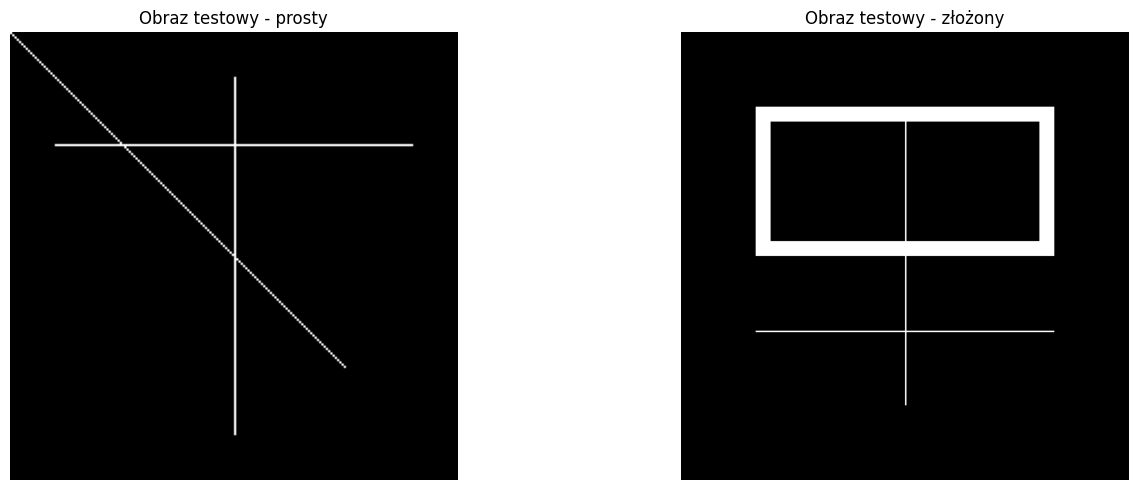

In [30]:
def create_test_image_simple():
    """Tworzy prosty obraz testowy z kilkoma liniami."""
    img = np.zeros((200, 200), dtype=np.uint8)
    
    # Linia pozioma
    img[50, 20:180] = 255
    
    # Linia pionowa
    img[20:180, 100] = 255
    
    # Linia ukośna
    for i in range(150):
        if 0 <= i < 200 and 0 <= i < 200:
            img[i, i] = 255
    
    return img

def create_test_image_complex():
    """Tworzy bardziej złożony obraz testowy."""
    img = np.zeros((300, 300), dtype=np.uint8)
    
    # Prostokąt
    img[50:150, 50:250] = 255
    img[60:140, 60:240] = 0
    
    # Dodatkowe linie
    img[200, 50:250] = 255
    img[50:250, 150] = 255
    
    return img

# Utworzenie obrazów testowych
test_img_simple = create_test_image_simple()
test_img_complex = create_test_image_complex()

show_images([test_img_simple, test_img_complex], 
            ['Obraz testowy - prosty', 'Obraz testowy - złożony'])

---

## 3. Zadania do wykonania

### Zadanie 1: Detekcja krawędzi

Zaimplementuj funkcję `detect_edges_for_hough(img, low_threshold, high_threshold)`, która:
1. Zastosuje filtr Gaussa do wygładzenia obrazu (rozmiar kernela 5×5, sigma=1.4)
2. Użyje operatora Sobela do obliczenia gradientów
3. Zastosuje progowanie z histerezą (podobnie jak w detektorze Canny'ego):
   - Piksele z gradientem > `high_threshold` są silnymi krawędziami
   - Piksele z gradientem > `low_threshold` są słabymi krawędziami
   - Słabe krawędzie są akceptowane tylko jeśli są połączone z silnymi
4. Zwróci binarną mapę krawędzi

**Wskazówki:**
- Użyj `scipy.ndimage.gaussian_filter` do wygładzenia
- Możesz użyć funkcji `sobel_filters` z kodu startowego
- Do progowania z histerezą możesz użyć `cv2.Canny` lub zaimplementować własną wersję

**Testowanie:**
```python
edges = detect_edges_for_hough(test_img_simple, low_threshold=50, high_threshold=100)
show_image(edges, 'Wykryte krawędzie')
```

In [31]:
# ZADANIE 1: Twoja implementacja tutaj

def edge_detection(img, low_threshold=50, high_threshold=100):
    """
    Detekcja krawędzi dla transformaty Hougha.
    
    Args:
        img: obraz wejściowy (skala szarości)
        low_threshold: dolny próg dla progowania z histerezą
        high_threshold: górny próg dla progowania z histerezą
    
    Returns:
        edges: binarna mapa krawędzi (0 lub 255)
    """
    # TODO: Implementacja
    pass

# Testowanie
# edges = edge_detection(test_img_simple, low_threshold=50, high_threshold=100)
# show_image(edges, 'Wykryte krawędzie')

#### DO USUNIECIA PRZED ZAJĘCIAMI

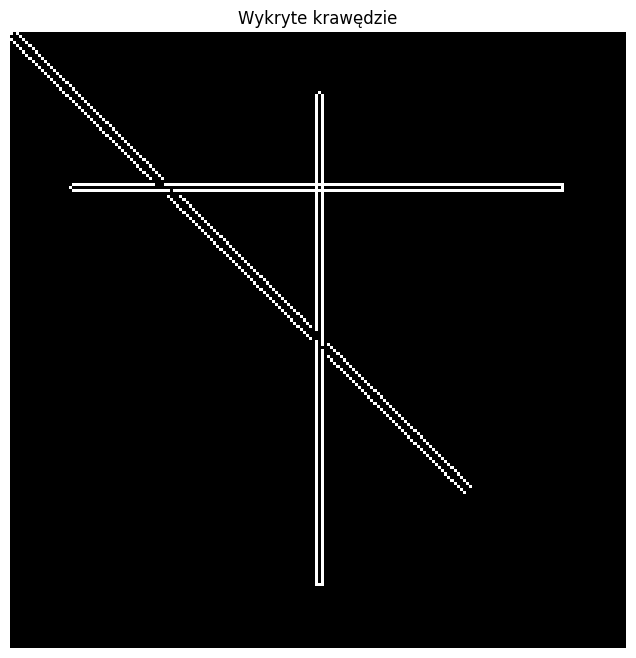

In [32]:
def edge_detection(img, low_threshold=50, high_threshold=150):
    """
    Detekcja krawędzi metodą Canny.
    """
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img.copy()

    edges = cv2.Canny(gray, low_threshold, high_threshold)
    return edges

# Testowanie
edges = edge_detection(test_img_simple)
show_image(edges, 'Wykryte krawędzie')

### Zadanie 2: Implementacja akumulatora Hougha

Zaimplementuj funkcję `hough_transform(edges, theta_resolution=1, rho_resolution=1)`, która:
1. Utworzy akumulator Hougha o odpowiednich rozmiarach:
   - Zakres $\theta$: od 0° do 180° z krokiem `theta_resolution`
   - Zakres $\rho$: od $-\rho_{max}$ do $\rho_{max}$ z krokiem `rho_resolution`
   - gdzie $\rho_{max} = \sqrt{width^2 + height^2}$
2. Dla każdego piksela krawędzi (gdzie wartość > 0):
   - Iteruje przez wszystkie kąty $\theta$
   - Oblicza odpowiadające $\rho = x \cos\theta + y \sin\theta$
   - Zwiększa wartość w akumulatorze `H[ρ][θ] += 1`
3. Zwróci:
   - Akumulator `H`
   - Tablicę wartości $\theta$ (w radianach)
   - Tablicę wartości $\rho$

**Wskazówki:**
- Pamiętaj o konwersji stopni na radiany: `np.deg2rad()`
- Indeksowanie akumulatora: $\rho$ może być ujemne, więc trzeba przesunąć indeks
- Użyj `np.round()` do zaokrąglenia wartości $\rho$ do najbliższego indeksu

**Testowanie:**
```python
H, thetas, rhos = hough_transform(edges)
plt.imshow(H, cmap='hot', aspect='auto')
plt.xlabel('Theta (stopnie)')
plt.ylabel('Rho (piksele)')
plt.title('Akumulator Hougha')
plt.colorbar(label='Liczba głosów')
plt.show()
```

In [33]:
# ZADANIE 2: Twoja implementacja tutaj

def hough_transform(edges, theta_resolution=1, rho_resolution=1):
    """
    Transformata Hougha dla detekcji linii prostych.
    
    Args:
        edges: binarna mapa krawędzi
        theta_resolution: rozdzielczość kąta w stopniach
        rho_resolution: rozdzielczość odległości w pikselach
    
    Returns:
        H: akumulator Hougha
        thetas: tablica wartości theta (w radianach)
        rhos: tablica wartości rho
    """
    # TODO: Implementacja
    pass

# Testowanie
# H, thetas, rhos = hough_transform(edges)
# plt.imshow(H, cmap='hot', aspect='auto')
# plt.xlabel('Theta (stopnie)')
# plt.ylabel('Rho (piksele)')
# plt.title('Akumulator Hougha')
# plt.colorbar(label='Liczba głosów')
# plt.show()

#### DO USUNIECIA PRZED ZAJĘCIAMI

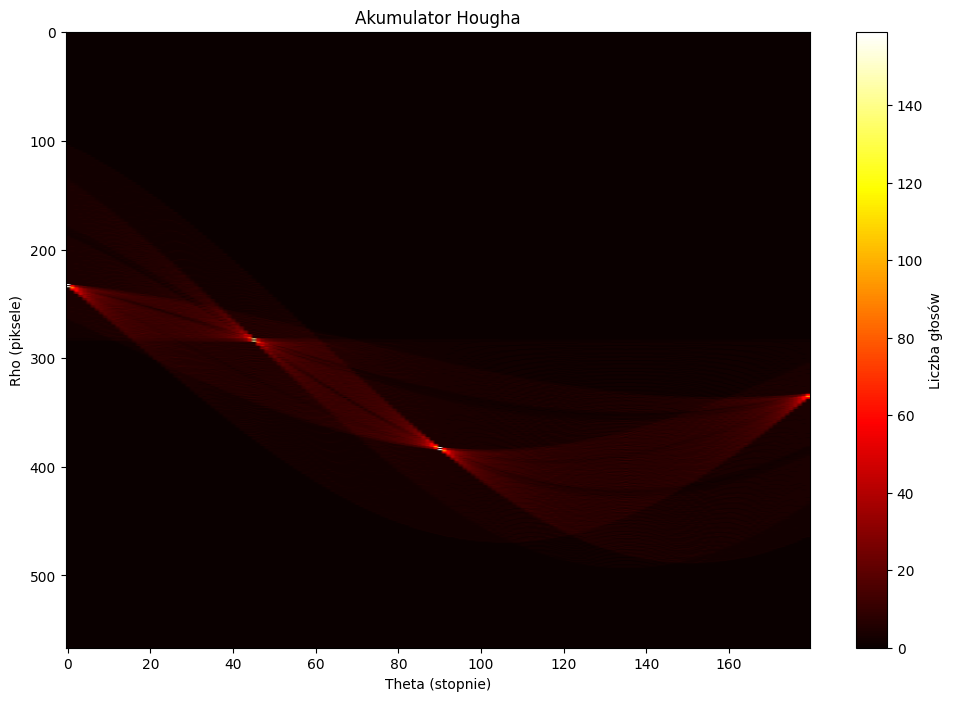

In [34]:
def hough_transform(edges, theta_res=1, rho_res=1):
    """
    Klasyczna transformata Hougha dla linii prostych.
    """
    height, width = edges.shape
    diag_len = int(np.ceil(np.sqrt(height**2 + width**2)))

    rhos = np.arange(-diag_len, diag_len + 1, rho_res)
    thetas = np.deg2rad(np.arange(-90, 90, theta_res))

    H = np.zeros((len(rhos), len(thetas)), dtype=np.uint64)

    y_idxs, x_idxs = np.nonzero(edges)

    for x, y in zip(x_idxs, y_idxs):
        for t_idx, theta in enumerate(thetas):
            rho = int(round(x * np.cos(theta) + y * np.sin(theta))) + diag_len
            H[rho, t_idx] += 1

    return H, thetas, rhos

# Testowanie
H, thetas, rhos = hough_transform(edges)
plt.imshow(H, cmap='hot', aspect='auto')
plt.xlabel('Theta (stopnie)')
plt.ylabel('Rho (piksele)')
plt.title('Akumulator Hougha')
plt.colorbar(label='Liczba głosów')
plt.show()

### Zadanie 3: Wykrywanie linii

Zaimplementuj funkcję `detect_lines(H, thetas, rhos, threshold, nms_window=5)`, która:
1. Znajdzie lokalne maksima w akumulatorze Hougha
2. Zastosuje progowanie: wybierze tylko te maksima, które przekraczają `threshold`
3. Opcjonalnie zastosuje tłumienie niemaksimów (Non-Maximum Suppression):
   - W oknie `nms_window × nms_window` wokół każdego maksimum
   - Zachowa tylko najsilniejsze maksimum w danym oknie
4. Zwróci listę wykrytych linii jako listę krotek `(rho, theta)`

**Wskazówki:**
- Użyj `scipy.ndimage.maximum_filter` do znalezienia lokalnych maksimów
- Maksimum lokalne to piksel, który ma taką samą wartość jak maksimum w swoim sąsiedztwie
- Sortuj wykryte linie według liczby głosów (malejąco)

**Testowanie:**
```python
lines = detect_lines(H, thetas, rhos, threshold=50, nms_window=10)
print(f"Wykryto {len(lines)} linii")
for i, (rho, theta) in enumerate(lines[:5]):
    print(f"Linia {i+1}: ρ={rho:.2f}, θ={np.rad2deg(theta):.2f}°")
```

In [35]:
# ZADANIE 3: Twoja implementacja tutaj

def detect_lines(H, thetas, rhos, threshold, nms_window=5):
    """
    Wykrywa linie proste na podstawie akumulatora Hougha.
    
    Args:
        H: akumulator Hougha
        thetas: tablica wartości theta
        rhos: tablica wartości rho
        threshold: minimalny próg liczby głosów
        nms_window: rozmiar okna dla tłumienia niemaksimów
    
    Returns:
        lines: lista krotek (rho, theta) reprezentujących wykryte linie
    """
    # TODO: Implementacja
    pass

# Testowanie
# lines = detect_lines(H, thetas, rhos, threshold=50, nms_window=10)
# print(f"Wykryto {len(lines)} linii")
# for i, (rho, theta) in enumerate(lines[:5]):
#     print(f"Linia {i+1}: ρ={rho:.2f}, θ={np.rad2deg(theta):.2f}°")

#### DO USUNIECIA PRZED ZAJĘCIAMI

In [36]:
def detect_lines(H, thetas, rhos, threshold, nms_window=5):
    """
    Wykrywa linie proste na podstawie akumulatora Hougha.
    """
    lines = []
    H_nms = H.copy()

    half_w = nms_window // 2

    for i in range(H.shape[0]):
        for j in range(H.shape[1]):
            if H[i, j] < threshold:
                continue

            i_min = max(i - half_w, 0)
            i_max = min(i + half_w + 1, H.shape[0])
            j_min = max(j - half_w, 0)
            j_max = min(j + half_w + 1, H.shape[1])

            if H[i, j] == np.max(H[i_min:i_max, j_min:j_max]):
                lines.append((rhos[i], thetas[j]))

    return lines

# Testowanie
lines = detect_lines(H, thetas, rhos, threshold=50, nms_window=10)
print(f"Wykryto {len(lines)} linii")
for i, (rho, theta) in enumerate(lines[:5]):
    print(f"Linia {i+1}: ρ={rho:.2f}, θ={np.rad2deg(theta):.2f}°")

Wykryto 5 linii
Linia 1: ρ=-51.00, θ=-90.00°
Linia 2: ρ=-1.00, θ=-45.00°
Linia 3: ρ=1.00, θ=-45.00°
Linia 4: ρ=52.00, θ=89.00°
Linia 5: ρ=101.00, θ=0.00°


### Zadanie 4: Rysowanie wykrytych linii

Zaimplementuj funkcję `draw_lines(img, lines, color=(255, 0, 0), thickness=2)`, która:
1. Dla każdej linii określonej przez $(\rho, \theta)$:
   - Obliczy punkty przecięcia linii z brzegami obrazu
   - Narysuje linię na obrazie
2. Zwróci obraz z narysowanymi liniami

**Algorytm rysowania linii:**
- Dla danego $(\rho, \theta)$ linia jest określona przez: $\rho = x \cos\theta + y \sin\theta$
- Znajdź punkty przecięcia z brzegami obrazu:
  - Dla $x = 0$: $y = \rho / \sin\theta$ (jeśli $\sin\theta \neq 0$)
  - Dla $x = width$: $y = (\rho - width \cos\theta) / \sin\theta$
  - Dla $y = 0$: $x = \rho / \cos\theta$ (jeśli $\cos\theta \neq 0$)
  - Dla $y = height$: $x = (\rho - height \sin\theta) / \cos\theta$
- Wybierz dwa punkty, które leżą w granicach obrazu
- Użyj `cv2.line()` do narysowania linii

**Wskazówki:**
- Konwertuj obraz do RGB jeśli jest w skali szarości: `cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)`
- Sprawdź czy punkty leżą w granicach obrazu: `0 <= x < width` i `0 <= y < height`

**Testowanie:**
```python
result = draw_lines(test_img_simple, lines[:5])
show_image(result, 'Wykryte linie', cmap=None)
```

In [37]:
# ZADANIE 4: Twoja implementacja tutaj

def draw_lines(img, lines, color=(255, 0, 0), thickness=2):
    """
    Rysuje wykryte linie na obrazie.
    
    Args:
        img: obraz wejściowy
        lines: lista krotek (rho, theta) reprezentujących linie
        color: kolor linii (R, G, B)
        thickness: grubość linii
    
    Returns:
        result: obraz z narysowanymi liniami
    """
    # TODO: Implementacja
    pass

# Testowanie
# result = draw_lines(test_img_simple, lines[:5])
# show_image(result, 'Wykryte linie', cmap=None)

#### DO USUNIECIA PRZED ZAJĘCIAMI

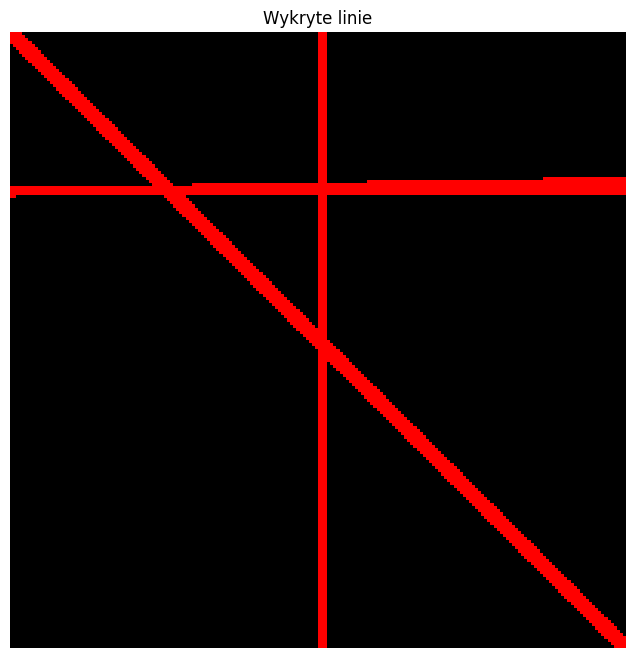

In [38]:
def draw_lines(img, lines, color=(255, 0, 0), thickness=2):
    """
    Rysuje wykryte linie na obrazie.
    """
    if len(img.shape) == 2:
        result = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    else:
        result = img.copy()

    h, w = result.shape[:2]

    for rho, theta in lines:
        a = np.cos(theta)
        b = np.sin(theta)

        x0 = a * rho
        y0 = b * rho

        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))

        cv2.line(result, (x1, y1), (x2, y2), color, thickness)

    return result

# Testowanie
result = draw_lines(test_img_simple, lines[:5])
show_image(result, 'Wykryte linie', cmap=None)

### Zadanie 5: Kompletny pipeline detekcji linii

Połącz wszystkie poprzednie funkcje w jeden pipeline `hough_line_detection(img, edge_low, edge_high, hough_threshold, nms_window)`, który:
1. Wykryje krawędzie
2. Zastosuje transformatę Hougha
3. Wykryje linie
4. Narysuje wykryte linie na oryginalnym obrazie
5. Wyświetli wszystkie etapy przetwarzania

**Testowanie:**
```python
result = hough_line_detection(test_img_complex, 
                              edge_low=50, 
                              edge_high=100, 
                              hough_threshold=60, 
                              nms_window=10)
```

In [39]:
# ZADANIE 5: Twoja implementacja tutaj

def hough_line_detection(img, edge_low=50, edge_high=100, hough_threshold=50, nms_window=10):
    """
    Kompletny pipeline detekcji linii za pomocą transformaty Hougha.
    
    Args:
        img: obraz wejściowy (skala szarości)
        edge_low: dolny próg dla detekcji krawędzi
        edge_high: górny próg dla detekcji krawędzi
        hough_threshold: próg dla akumulatora Hougha
        nms_window: rozmiar okna dla tłumienia niemaksimów
    
    Returns:
        result: obraz z narysowanymi wykrytymi liniami
    """
    # TODO: Implementacja
    pass

# Testowanie
# result = hough_line_detection(test_img_complex, 
#                               edge_low=50, 
#                               edge_high=100, 
#                               hough_threshold=60, 
#                               nms_window=10)

#### DO USUNIECIA PRZED ZAJĘCIAMI

In [40]:
def hough_line_detection(img, edge_low=50, edge_high=100, hough_threshold=50, nms_window=10):
    """
    Kompletny pipeline detekcji linii prostych.
    """
    edges = edge_detection(img, edge_low, edge_high)

    H, thetas, rhos = hough_transform(edges)

    lines = detect_lines(H, thetas, rhos, hough_threshold, nms_window)

    result = draw_lines(img, lines)

    plt.figure(figsize=(15, 8))

    plt.subplot(2, 3, 1)
    plt.title("obraz oryginalny")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(2, 3, 2)
    plt.title("krawędzie")
    plt.imshow(edges, cmap="gray")
    plt.axis("off")

    plt.subplot(2, 3, 3)
    plt.title("akumulator Hougha")
    plt.imshow(H, cmap="hot", aspect="auto")
    plt.axis("off")

    plt.subplot(2, 3, 4)
    plt.title("wykryte linie")
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    return result


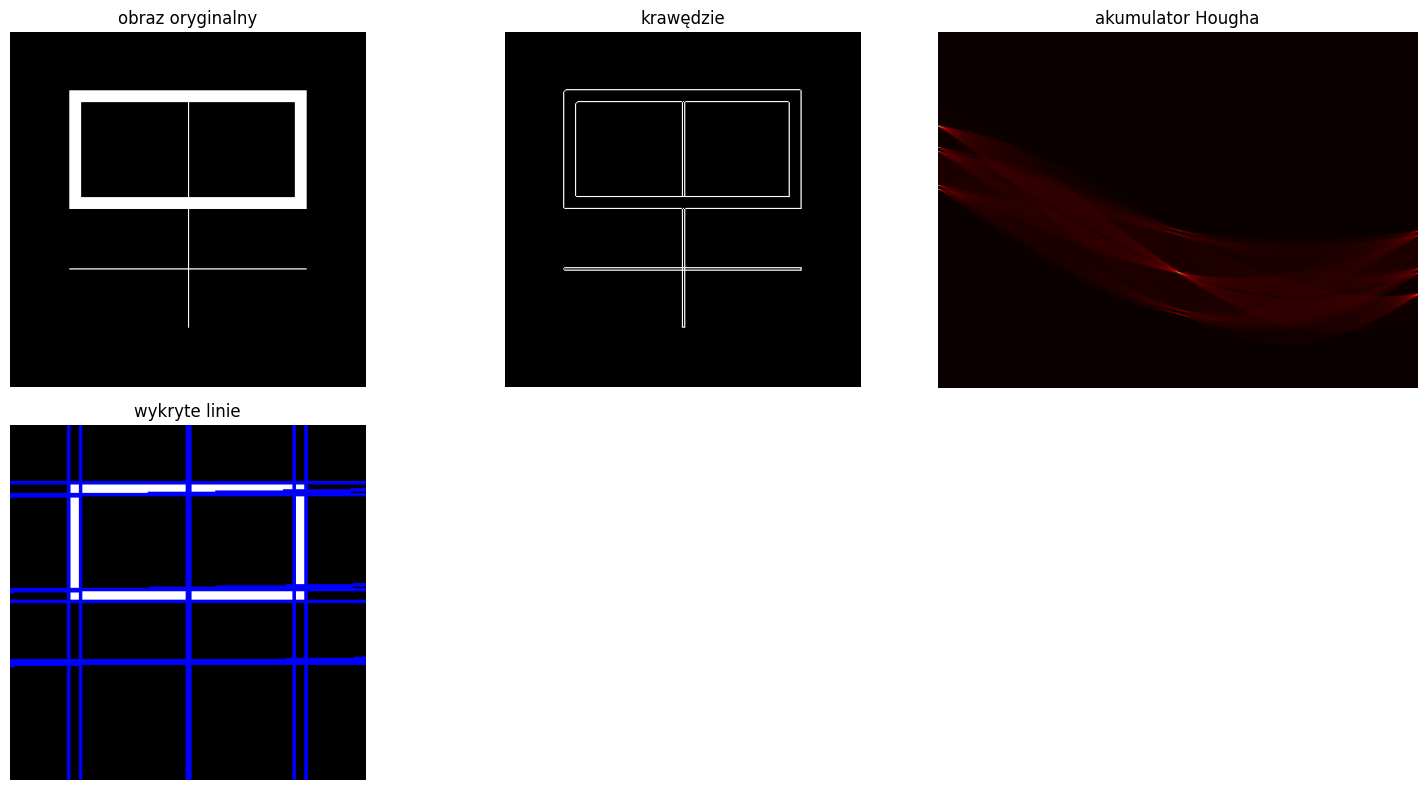

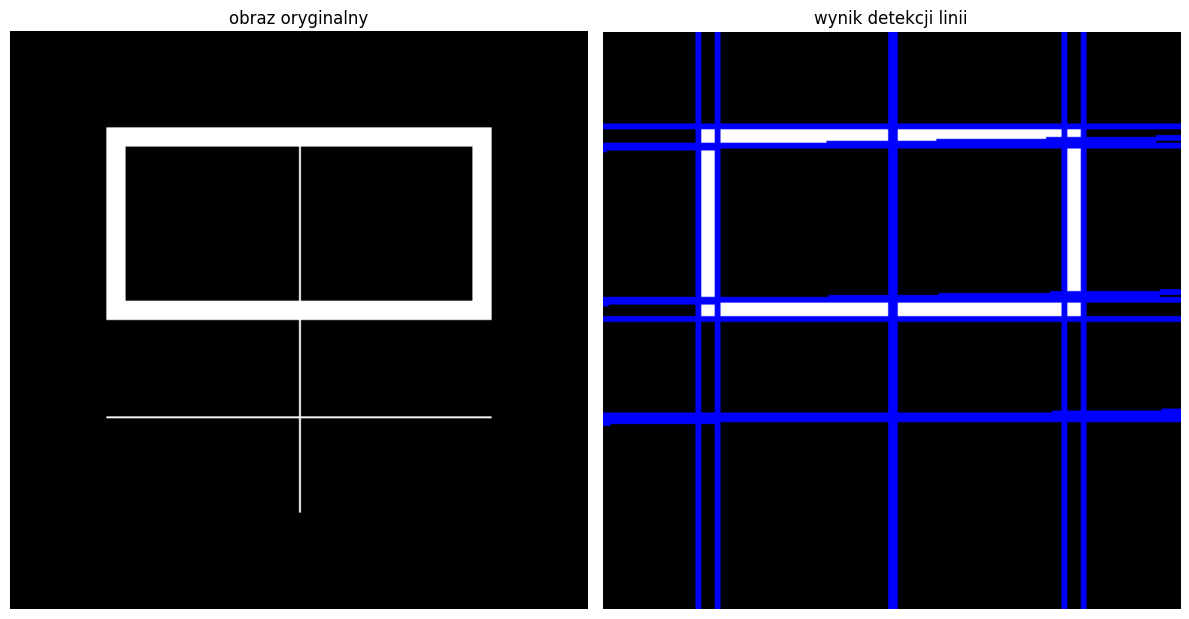

In [41]:
# Testowanie
result = hough_line_detection(test_img_complex, 
                              edge_low=50, 
                              edge_high=100, 
                              hough_threshold=60, 
                              nms_window=10)
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(test_img_complex, cv2.COLOR_BGR2RGB))
plt.title("obraz oryginalny")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("wynik detekcji linii")
plt.axis("off")

plt.tight_layout()
plt.show()


---

## 4. Zadania dodatkowe (opcjonalne)

### Zadanie 6*: Test na rzeczywistym obrazie (bonus 1 pkt)

Wczytaj rzeczywisty obraz (np. zdjęcie budynku, drogi, dokumentu) i zastosuj na nim detekcję linii. Eksperymentuj z parametrami, aby uzyskać najlepsze wyniki.

**Wskazówki:**
- Możesz użyć obrazów z OpenCV: `cv2.imread('path/to/image.jpg', 0)`
- Dostosuj parametry progowania w zależności od obrazu
- Porównaj wyniki z wbudowaną funkcją OpenCV: `cv2.HoughLines()`

Lena - rozmiar: (512, 512), typ: uint8


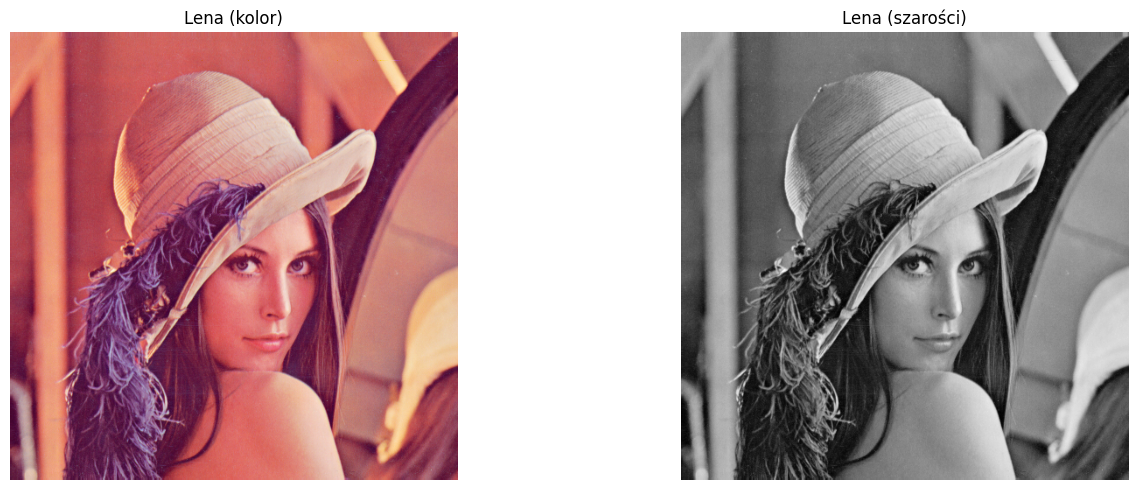

In [44]:
from PIL import Image
import urllib.request

def rgb_to_gray(img):
    """Konwersja RGB -> skala szarości (wzór ITU-R BT.601)"""
    if len(img.shape) == 2:
        return img
    return np.dot(img[...,:3], [0.299, 0.587, 0.114]).astype(np.uint8)

def display_images(images, titles=None, cmap='gray', figsize=(15, 5)):
    """Wyświetlanie wielu obrazów obok siebie"""
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for i, (img, ax) in enumerate(zip(images, axes)):
        ax.imshow(img, cmap=cmap)
        ax.axis('off')
        if titles:
            ax.set_title(titles[i])
    plt.tight_layout()
    plt.show()
    
url_lena = 'https://raw.githubusercontent.com/kbor89/TWiPO/main/images/lenna.png'
urllib.request.urlretrieve(url_lena, 'lena.png')
img_lena_color = np.array(Image.open('lena.png'))
img_lena = rgb_to_gray(img_lena_color).astype(np.uint8)


print(f"Lena - rozmiar: {img_lena.shape}, typ: {img_lena.dtype}")
display_images([img_lena_color, img_lena], ['Lena (kolor)', 'Lena (szarości)'])

In [ ]:
# ZADANIE 6*: Twoja implementacja tutaj

# Wczytaj własny obraz
# real_img = load_image_grayscale('path/to/your/image.jpg')
# result = hough_line_detection(real_img, edge_low=50, edge_high=150, hough_threshold=100)
# show_image(result, 'Detekcja linii na rzeczywistym obrazie', cmap=None)

#### DO USUNIECIA PRZED ZAJĘCIAMI

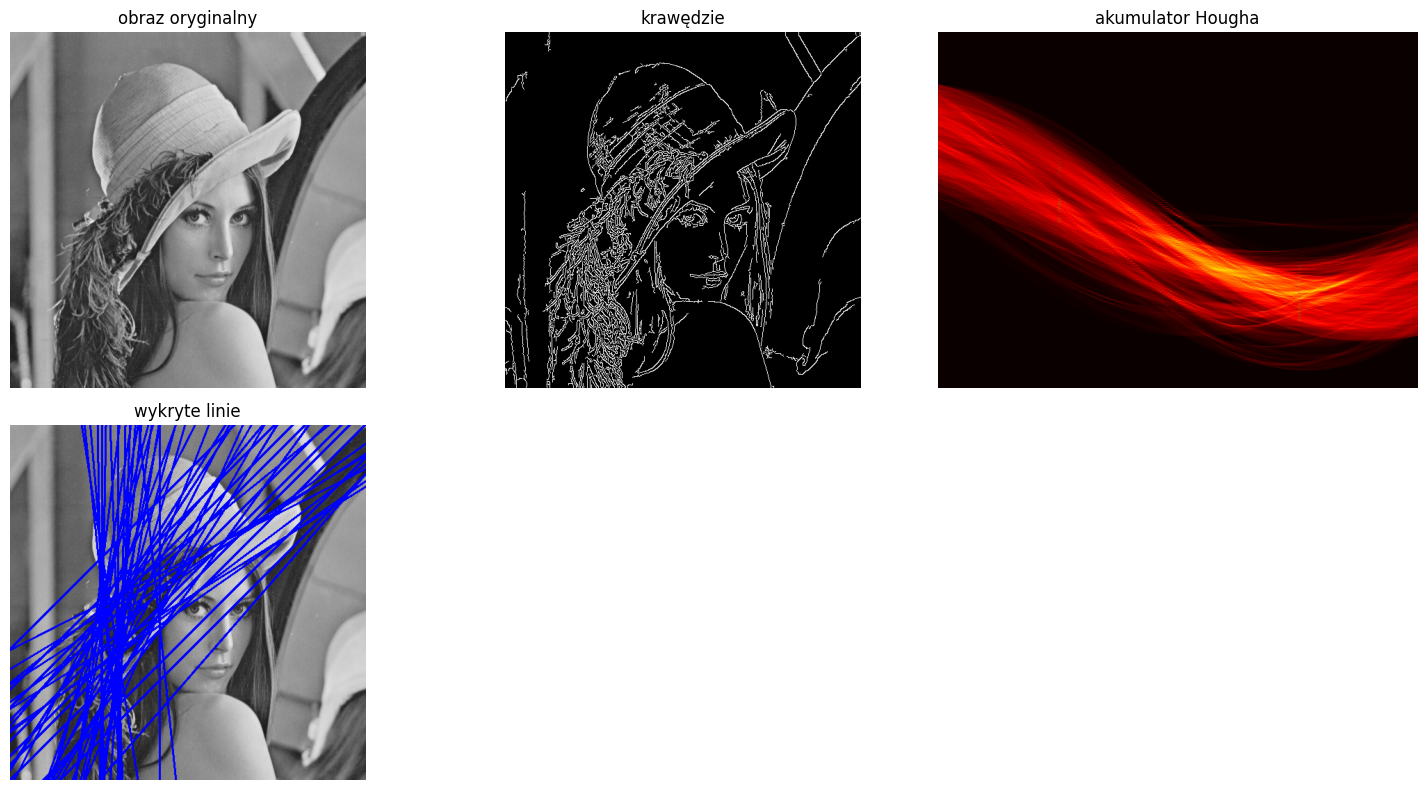

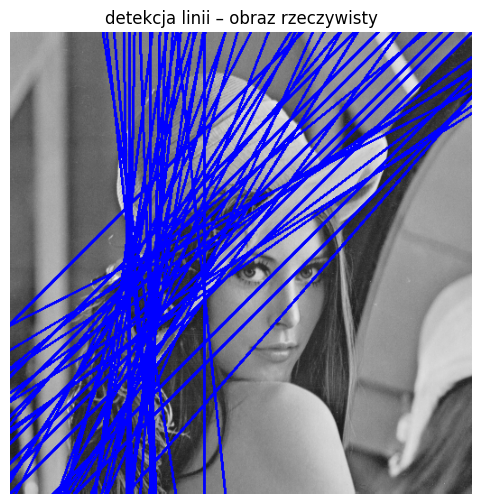

In [45]:
img_real = img_lena

result = hough_line_detection(
    img_real,
    edge_low=50,
    edge_high=150,
    hough_threshold=120,
    nms_window=10
)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("detekcja linii – obraz rzeczywisty")
plt.axis("off")
plt.show()


### Zadanie 7*: Porównanie z OpenCV

Porównaj swoją implementację z wbudowaną funkcją `cv2.HoughLines()` z biblioteki OpenCV:
1. Zastosuj obie metody na tym samym obrazie
2. Porównaj wyniki wizualnie
3. Zmierz czas wykonania obu metod
4. Przeanalizuj różnice w wykrytych liniach

**Dokumentacja OpenCV:**
```python
lines = cv2.HoughLines(edges, rho=1, theta=np.pi/180, threshold=100)
```

In [ ]:
# ZADANIE 7*: Twoja implementacja tutaj

import time

# Porównanie z OpenCV
# edges = detect_edges_for_hough(test_img_complex)

# Twoja implementacja
# start = time.time()
# H, thetas, rhos = hough_transform(edges)
# lines_custom = detect_lines(H, thetas, rhos, threshold=60)
# time_custom = time.time() - start

# OpenCV
# start = time.time()
# lines_cv = cv2.HoughLines(edges, 1, np.pi/180, 60)
# time_cv = time.time() - start

# print(f"Czas wykonania (własna implementacja): {time_custom:.4f}s")
# print(f"Czas wykonania (OpenCV): {time_cv:.4f}s")
# print(f"Liczba wykrytych linii (własna): {len(lines_custom)}")
# print(f"Liczba wykrytych linii (OpenCV): {len(lines_cv) if lines_cv is not None else 0}")

#### DO USUNIECIA PRZED ZAJĘCIAMI

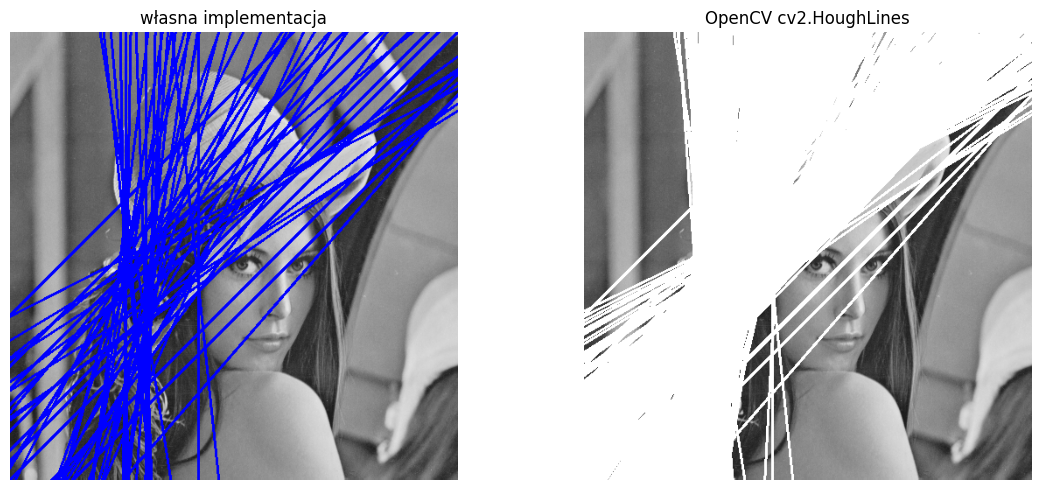

In [46]:
edges = edge_detection(img_real, 50, 150)

lines_cv = cv2.HoughLines(edges, rho=1, theta=np.pi/180, threshold=120)

img_cv = img_real.copy()

if lines_cv is not None:
    for line in lines_cv:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(img_cv, (x1, y1), (x2, y2), (255, 0, 0), 2)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("własna implementacja")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
plt.title("OpenCV cv2.HoughLines")
plt.axis("off")

plt.tight_layout()
plt.show()


### Zadanie 8*: Probabilistyczna transformata Hougha

Zaimplementuj probabilistyczną wersję transformaty Hougha, która:
1. Losowo wybiera podzbiór pikseli krawędzi (np. 30-50%)
2. Wykonuje transformatę Hougha tylko na wybranych pikselach
3. Porównaj wyniki i czas wykonania z pełną transformatą

**Wskazówki:**
- Użyj `np.random.choice()` do losowego wyboru pikseli
- Eksperymentuj z różnymi procentami próbkowania
- Oceń wpływ na dokładność i szybkość

In [ ]:
# ZADANIE 8*: Twoja implementacja tutaj

def probabilistic_hough_transform(edges, sampling_ratio=0.3, theta_resolution=1, rho_resolution=1):
    """
    Probabilistyczna transformata Hougha.
    
    Args:
        edges: binarna mapa krawędzi
        sampling_ratio: procent pikseli do próbkowania (0.0 - 1.0)
        theta_resolution: rozdzielczość kąta w stopniach
        rho_resolution: rozdzielczość odległości w pikselach
    
    Returns:
        H: akumulator Hougha
        thetas: tablica wartości theta
        rhos: tablica wartości rho
    """
    # TODO: Implementacja
    pass

# Testowanie
# edges = detect_edges_for_hough(test_img_complex)
# H_prob, thetas, rhos = probabilistic_hough_transform(edges, sampling_ratio=0.3)
# lines_prob = detect_lines(H_prob, thetas, rhos, threshold=30)
# result_prob = draw_lines(test_img_complex, lines_prob)
# show_image(result_prob, 'Probabilistyczna transformata Hougha', cmap=None)

#### DO USUNIECIA PRZED ZAJĘCIAMI

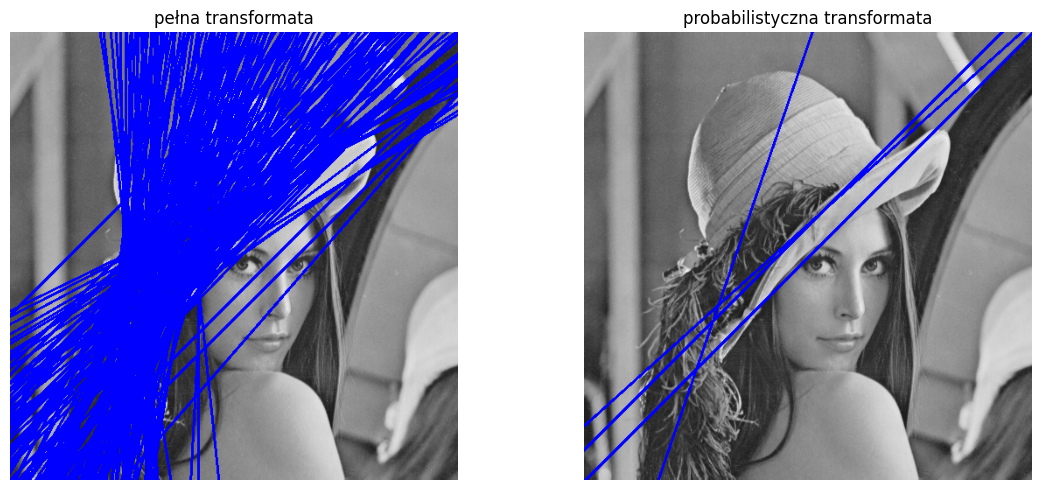

In [47]:
def hough_transform_probabilistic(edges, sample_ratio=0.4, theta_res=1, rho_res=1):
    height, width = edges.shape
    diag_len = int(np.ceil(np.sqrt(height**2 + width**2)))

    rhos = np.arange(-diag_len, diag_len + 1, rho_res)
    thetas = np.deg2rad(np.arange(-90, 90, theta_res))

    H = np.zeros((len(rhos), len(thetas)), dtype=np.uint64)

    y_idxs, x_idxs = np.nonzero(edges)
    n_points = len(x_idxs)

    sample_size = int(sample_ratio * n_points)
    idxs = np.random.choice(n_points, sample_size, replace=False)

    for idx in idxs:
        x = x_idxs[idx]
        y = y_idxs[idx]
        for t_idx, theta in enumerate(thetas):
            rho = int(round(x * np.cos(theta) + y * np.sin(theta))) + diag_len
            H[rho, t_idx] += 1

    return H, thetas, rhos


edges = edge_detection(img_real, 50, 150)

H_full, thetas, rhos = hough_transform(edges)
H_prob, thetas_p, rhos_p = hough_transform_probabilistic(edges, sample_ratio=0.4)

lines_full = detect_lines(H_full, thetas, rhos, 120)
lines_prob = detect_lines(H_prob, thetas_p, rhos_p, 80)

img_full = draw_lines(img_real, lines_full)
img_prob = draw_lines(img_real, lines_prob)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_full, cv2.COLOR_BGR2RGB))
plt.title("pełna transformata")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_prob, cv2.COLOR_BGR2RGB))
plt.title("probabilistyczna transformata")
plt.axis("off")

plt.tight_layout()
plt.show()


---

## 5. Podsumowanie

W tym laboratorium nauczyłeś/aś się:
- Jak działa transformata Hougha i jej zastosowanie do detekcji linii prostych
- Jak reprezentować proste w przestrzeni parametrów $(\rho, \theta)$
- Jak zbudować akumulator Hougha i wykrywać linie na podstawie lokalnych maksimów
- Jak rysować wykryte linie na obrazie
- Jak optymalizować detekcję za pomocą tłumienia niemaksimów

**Dalsze kierunki:**
- Transformata Hougha dla okręgów i elips
- Uogólniona transformata Hougha (Generalized Hough Transform)
- Detekcja segmentów linii zamiast nieskończonych prostych
- Zastosowania w robotyce i nawigacji autonomicznej

**Literatura:**
1. Duda, R. O., & Hart, P. E. (1972). "Use of the Hough transformation to detect lines and curves in pictures"
2. Ballard, D. H. (1981). "Generalizing the Hough transform to detect arbitrary shapes"
3. Matas, J., Galambos, C., & Kittler, J. (2000). "Robust detection of lines using the progressive probabilistic Hough transform"

---

**Powodzenia!** 🚀